# Profile your run

> Three numbers tell you where a run's time went -- compiling the kernel,
> running it, and bringing the result home -- before you ever reach for a
> profiler.

**Time:** ~4 min · **Runs on:** CPU (GPU: this notebook picks it up
automatically) · **You need:** {doc}`05_steps_per_launch`

You will build the figure below: a build / run / transfer breakdown of your
own run, on your own machine.

In [1]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent.parent / "_shared"))
from nb_helpers import gpu_available, to_numpy, xp_for


In [2]:
import time

DEVICE = "gpu" if gpu_available() else "cpu"
xp = xp_for(DEVICE)
print("running on", DEVICE)

running on cpu


## The code: timing the three phases yourself

{class}`~eagle.RunReport` (what {func}`eagle.until_done`'s runner hands back)
already carries `build_s`, the one-time graph-capture cost (zero on the
host, since there is no graph to build there). Wrapping the run itself in
`time.perf_counter()` and timing the step that brings the result home with
`to_host` gives the other two numbers, with no extra dependency.

In [3]:
import eagle
import hawk
from hawk import Mutable, Param, Scalar, Terminated


@hawk.kernel(steps="auto")
def oscillator(omega: Scalar, t_end: Param, dt: Param, terminated: Terminated,
               x: Mutable[Scalar], v: Mutable[Scalar], t: Mutable[Scalar]):
    x0, v0 = x, v
    x = x0 + dt * v0
    v = v0 - dt * omega * omega * x0
    t += dt
    terminated = t >= t_end


n = 1_000_000 if DEVICE == "gpu" else 100_000
planes = dict(x=xp.ones(n), v=xp.zeros(n), t=xp.zeros(n),
              omega=xp.linspace(1.0, 3.0, n), t_end=1.0, dt=1e-3)
runner = eagle.until_done(eagle.deploy(oscillator), max_steps=10_000, **planes)

t0 = time.perf_counter()
report = runner.run()
t1 = time.perf_counter()
x_home = to_numpy(planes["x"])      # the only step that actually moves data home
t2 = time.perf_counter()

build_s = report.build_s
run_s = max((t1 - t0) - build_s, 0.0)
transfer_s = t2 - t1
print(f"build: {build_s * 1e3:.2f} ms, run: {run_s * 1e3:.2f} ms, "
      f"transfer: {transfer_s * 1e3:.2f} ms")
print(f"launches: {report.launches}, steps: {report.steps}, "
      f"launches_by_k: {report.launches_by_k}")

build: 0.00 ms, run: 60.61 ms, transfer: 0.05 ms
launches: 16, steps: 1024, launches_by_k: {64: 16}


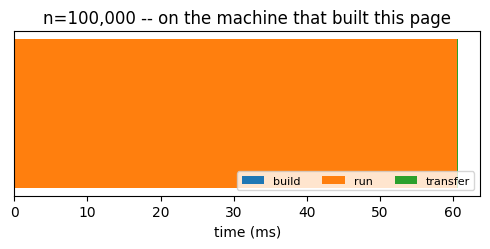

In [4]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(5, 2.6))
segments = [
    ("build", build_s, "C0"), ("run", run_s, "C1"), ("transfer", transfer_s, "C2"),
]
left = 0.0
for label, width_s, color in segments:
    ax.barh(0, width_s * 1e3, left=left * 1e3, color=color, label=label)
    left += width_s
ax.set_xlabel("time (ms)")
ax.set_yticks([])
ax.set_title(f"n={n:,} -- on the machine that built this page")
ax.legend(loc="lower right", ncols=3, fontsize=8)
fig.tight_layout()
plt.show()

## What just happened

- `report.build_s` is the one-time graph-capture cost {doc}`02_cuda_graphs_python`
  introduced; it is zero on the host team, since there is no graph to
  build there, and zero on any later `runner.run()` call that replays the
  same build.
- "run" is everything the loop itself did while it was out of Python's
  hands -- every launch, and every compaction or reorder `report.compactions`
  / `report.reorders` counts.
- "transfer" is only the last step: bringing the result home with
  `to_host`. On the host team there is nothing to bring home (the arrays
  were already there), so it reads as zero; on the device it is a real
  device-to-host copy.

## Why the first run is slower (GPU card)

<!-- stale-prose-gate:
benchmarks/rk78_card/card_quadro-p2000.json: 5fce90308cf314b6453a47b2e3a8641a
-->

The build time above already shows this, just smaller: a kernel nothing has
compiled yet pays hawk's build cost once. On the RK7(8) card, a cold run of
the eagle arms (`eagle graph` and `eagle.simulate` both deploy the
same hawk kernel) costs 3.36 s; the exact same kernel, rerun with a warm
cache -- even in a new process -- costs 527 ms. `eagle.deploy` and
`eagle.until_done` reuse hawk's own build cache, so only the very first call
in a fresh environment pays the cold price; every later one, in this
notebook or a new process pointed at the same cache, is warm.

## Useful FLOP/s vs. issued bytes/s

Two different yardsticks for the same run, in the performance card's own
words: **useful FLOP/s** counts only the steps of samples that are still
running -- a sample that already finished contributes nothing, no matter how
it is computed. **Issued bytes/s** counts the bytes an arm's own kernels
actually move, including the passes it makes over samples that already
finished. A kernel that compacts finished samples away can have low issued
bytes/s and still be fast; a plain kernel that always sweeps the whole batch
can issue a lot of bytes without doing much useful work. Both are also
reported as a fraction of the device's own peak -- the peaks `device_props()`
below reads off the hardware.

## Looking inside the kernels

The three numbers above come from Python; they don't say how long each GPU
*kernel* ran, or how many there were. Nsight Systems answers that from the
outside, with no code changes:

```bash
nsys profile --stats=true python run.py
```

`--stats=true` prints a kernel-by-kernel summary table to the terminal once
the trace finishes -- the same tool (with a longer flag list) the
performance card's own kernel-only numbers come from. This needs a CUDA GPU
and `nsys` installed, so it is shown here rather than run.

Device properties -- what `useful FLOP/s`/`issued bytes/s` are measured
against as a fraction of peak -- come from the compiled extension itself,
read once per device:

In [5]:
if DEVICE == "gpu":
    props = eagle.device_props()
    print(f"{props.name} -- {props.sm_count} SMs, "
          f"fp64 peak is 1/{props.fp64_ratio:.0f} of this card's fp32 peak")
else:
    print("eagle.device_props() needs a CUDA GPU; skipped on this machine.")

eagle.device_props() needs a CUDA GPU; skipped on this machine.


## Try this

Drop `max_steps` to `100` and re-run: `report.done` turns `False` -- the run
stopped at the cap, not because every sample finished -- and the "run"
segment above shrinks with it.

## Next

- {doc}`../examples/01_device_properties` (how-to) -- `device_props()`
  combined with a two-plugin force manifest.
- {doc}`../tutorials` -- the C++ track, if you want eagle's own graphs and
  kernels with no Python in between.
- deeper: {doc}`../../performance` ("Method") -- the full accounting this
  page borrows from.